In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load data 
df = pd.read_csv('/home/annrisper/SafiriSec/data/PS_20174392719_1491204439457_log.csv')

# Keep only cash out and transfer(fraud only happens here)
df = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])]

print("Filtered shape:", df.shape)
print("Fraud cases:", df['isFraud'].sum())

Filtered shape: (2770409, 11)
Fraud cases: 8213


In [6]:
# Select features for the model 
df = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

# Convert type column from text to numbers
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])#converts type cash out 0 and transfer 1

# Separate features (X) and target (y)
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2216327, 7)
Testing set size: (554082, 7)


In [10]:
# Calculate class weight from training data
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print("Negative (normal) transactions:", negative_count)
print("Positive (fraud) transactions:", positive_count)
print("scale_pos_weight:", scale_pos_weight)

# Train the XGBoost model
print("\nTraining model...this may take a few minutes")

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
print("Model training complete!")

Negative (normal) transactions: 2209757
Positive (fraud) transactions: 6570
scale_pos_weight: 336.34048706240486

Training model...this may take a few minutes
Model training complete!


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    552439
           1       0.28      0.99      0.44      1643

    accuracy                           0.99    554082
   macro avg       0.64      0.99      0.72    554082
weighted avg       1.00      0.99      0.99    554082



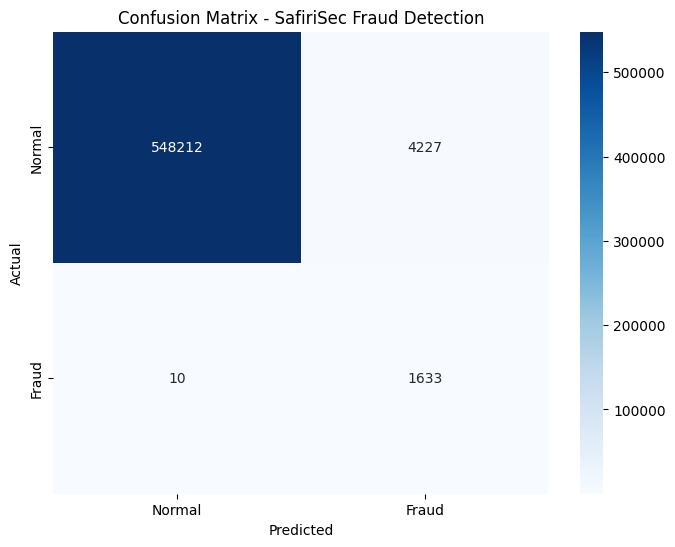

In [11]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluation
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - SafiriSec Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [12]:
import joblib

# Save the model
joblib.dump(model, '/home/annrisper/SafiriSec/models/fraud_model.pkl')
print("Model saved successfully!")

Model saved successfully!
